# Automated Customer Reviews
### Goal:
The goal is to create a NLP powered web application that aggregates and analyzes customer reviews.

### Main Functionality:
1. **Classification**: Classify reviews into categories such as positive, negative, and neutral.
    - Use a model if i feel like it, but I can also use a simple keyword-based approach for a baseline.
        - if model, then use pre-trained transformer-based model

2. **Product Category Clustering**: Simplify dataset by clustering product categories into broader groups.
    - Use a clustering algorithm like K-means or hierarchical clustering on product features.

3. **Review Summarization using LLMs**: Summarize reviews into articles that recoment top products in each category.
    - Use a pre-trained LLM (T5, Bart, or Groq) for summarisation.
    - Find top complaints and worst features for each product category and worst individual products.
    - Can also generate sentiment-based summaries and sentiment analysis reports as bonus features.


In [51]:
# imports
import pandas as pd
import os

# Classification:
0. **Data Loading**: Load the dataset of Amazon product reviews.
1. **Data Cleaning and Preprocessing**: Handle missing values, clean review text, and perform tokenization.
2. **Feature Extraction**: Convert text data into numerical features using techniques like TF-IDF or word embeddings.
3. **Running model**: Test for best model by comparing *metrics* vs *efficiency*
4. **Visuals**: Heatmap and metrics for comparability

## Data Source:
- **Local Dataset**: Kaggle dataset of Amazon product reviews (small subset for testing)

In [52]:
if not os.path.exists("data"):
    import kagglehub, shutil
    shutil.move(
        kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products"),
        os.path.join(os.getcwd(), "data"))

In [53]:
curr_dir = os.getcwd()

revs_df = pd.read_csv(os.path.join(curr_dir, "data", "1429_1.csv"))

revs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

/tmp/ipykernel_17176/1540874626.py:3: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  revs_df = pd.read_csv(os.path.join(curr_dir, "data", "1429_1.csv"))


## Data Cleaning and Preprocessing:
1. **Handling Missing Values**: Remove or impute missing values in the dataset.
2. **Text Preprocessing**: Clean review text by removing special characters, stop words, and performing tokenization.

In [54]:
useless_cols = [
    'id',
    'reviews.id', # not useful in our case
    'reviews.username', # might be useful for user-level analysis later
    'reviews.userCity', # might be useful for geographic analysis later
    'reviews.userProvince', # ^
    'manufacturer', # useless cuz all products are from the same manufacturer
    'reviews.sourceURLs',
    'keys',
    'asins', # not useful in our case
    'reviews.dateAdded',
    'reviews.dateSeen',
    'reviews.date',
    'reviews.didPurchase', # useless cuz only one value is True
]

In [55]:
def clean_data(df:pd.DataFrame, drop_cols:list=[]) -> pd.DataFrame:
    # Drops columns specified
    df_clean = df.drop(columns=drop_cols, errors="ignore").dropna(subset=["reviews.text", "reviews.rating"])

    # Drops rows that have NaN in these cols
    df_clean.dropna(subset=["name", "reviews.doRecommend"], inplace=True)

    # Replaces NaN values with False then
    df_clean.replace(pd.NA, False, inplace=True)

    # Make pd info work better
    df_clean["reviews.numHelpful"] = df_clean["reviews.numHelpful"].fillna(0).astype(int)
    df_clean["reviews.rating"] = df_clean["reviews.rating"].fillna(0).astype(int)
    df_clean["reviews.doRecommend"] = df_clean["reviews.doRecommend"].fillna(False).astype(bool)

    # Make sentiment column for classification
    def map_sentiment(rating):
      if rating >= 4:
          return "positive"
      elif rating == 3:
          return "neutral"
      else:
          return "negative"

    df_clean['reviews_sentiment'] = df_clean['reviews.rating'].map(map_sentiment)

    return df_clean

revs_df_clean = clean_data(revs_df, useless_cols)
revs_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27409 entries, 0 to 27899
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   name                 27409 non-null  object
 1   brand                27409 non-null  object
 2   categories           27409 non-null  object
 3   reviews.doRecommend  27409 non-null  bool  
 4   reviews.numHelpful   27409 non-null  int64 
 5   reviews.rating       27409 non-null  int64 
 6   reviews.text         27409 non-null  object
 7   reviews.title        27409 non-null  object
 8   reviews_sentiment    27409 non-null  object
dtypes: bool(1), int64(2), object(6)
memory usage: 1.9+ MB


/tmp/ipykernel_17176/2358444216.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean.replace(pd.NA, False, inplace=True)


In [56]:
revs_df_clean.sample(10)

,name,brand,categories,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.text,reviews.title,reviews_sentiment
10348,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",True,0,5,I bought this for my gran as a Christmas gift....,Great,positive
12867,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",False,0,3,not as good as the first kindle fire I got and...,ok,neutral
27806,"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",True,0,4,I got this to give voice activation to a Phill...,Great start for connected home,positive
19074,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,"Walmart for Business,Office Electronics,Tablet...",True,0,5,Have enjoyed using the touch screen to operate...,Easy to operate,positive
6303,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",True,1,5,Got this for my granddaughters birthday and sh...,great,positive
214,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",True,0,4,This is perfect my kids to do their school wor...,Perfect for my kids,positive
19641,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,"Walmart for Business,Office Electronics,Tablet...",True,0,4,Before I switched to the Kindle white I was us...,Miss seeing page numbers. Don't like location num,positive
11801,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",True,0,5,I love mine so much I bought my grandkids all ...,Lovin the fire,positive
3495,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Electronics,iPad & Tablets,All Tablets,Compute...",True,0,4,The Amazon Kindle is a good gift for the bookw...,Great Gift For The Bookworm!!!,positive
7160,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",True,0,5,The Amazon Fire is a great intro tablet. I got...,Great 7 entry tablet,positive


## Classification Model:
- Used "distilbert/distilbert-base-uncased-finetuned-sst-2-english" as model
- Merged title and text columns to give full context
- Ran model using GPU
  - kept non-GPU code
- Delivered results as Dict

In [57]:
from transformers import pipeline
import torch

classifier = pipeline(
                      task="text-classification",
                      model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
                      device=0,          # GPU
                      truncation=True,
                      max_length=512
                      )

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [58]:
rand_revs = revs_df_clean[["reviews.title", "reviews.text", "reviews_sentiment"]]

rand_revs['review_input'] = rand_revs['reviews.title'].fillna('').replace(False, '') + '. ' + rand_revs['reviews.text'].fillna('')
rand_revs['review_input'] = rand_revs['review_input'].str.strip()

rand_revs

/tmp/ipykernel_17176/868034416.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rand_revs['review_input'] = rand_revs['reviews.title'].fillna('').replace(False, '') + '. ' + rand_revs['reviews.text'].fillna('')
/tmp/ipykernel_17176/868034416.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rand_revs['review_input'] = rand_revs['review_input'].str.strip()


,reviews.title,reviews.text,reviews_sentiment,review_input
0,Kindle,This product so far has not disappointed. My c...,positive,Kindle. This product so far has not disappoint...
1,very fast,great for beginner or experienced person. Boug...,positive,very fast. great for beginner or experienced p...
2,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,positive,Beginner tablet for our 9 year old son.. Inexp...
3,Good!!!,I've had my Fire HD 8 two weeks now and I love...,positive,Good!!!. I've had my Fire HD 8 two weeks now a...
4,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,positive,Fantastic Tablet for kids. I bought this for m...
...,...,...,...,...
27895,My new favorite product,This is my new favorite device. While not perf...,positive,My new favorite product. This is my new favori...
27896,Lots of potential!!!,I got this to basically experiment with. Strai...,positive,Lots of potential!!!. I got this to basically ...
27897,Good First Generation Product,Good product that does the basics. Too bad you...,positive,Good First Generation Product. Good product th...
27898,"Great for a ""connected home""",This is great for a connected home. People who...,neutral,"Great for a ""connected home"". This is great fo..."


In [59]:
# GPU enhanced run
sentiment = {}
results = classifier(rand_revs['review_input'].tolist(), batch_size=64)

for text, result in zip(rand_revs['review_input'], results):
    sentiment[text[:40]] = [result['label'], result['score']]

In [60]:
# # normal run
# sentiment = {}
# for a in rand_revs['review_input']:
#   sentiment[a[:40]] = list(classifier(a)[0].values())

In [61]:
from numpy import average
sents = []
for a in list(sentiment.values()):
  sents.append(a[1])
print(f'Average confidence for the set: {round(average(sents),2)}')
sentiment

Average confidence for the set: 0.98


{'Kindle. This product so far has not disa': ['POSITIVE', 0.9996243715286255],
 'very fast. great for beginner or experie': ['POSITIVE', 0.9998339414596558],
 'Beginner tablet for our 9 year old son..': ['POSITIVE', 0.9985159039497375],
 "Good!!!. I've had my Fire HD 8 two weeks": ['POSITIVE', 0.9998138546943665],
 'Fantastic Tablet for kids. I bought this': ['POSITIVE', 0.997265100479126],
 'Just what we expected. This amazon fire ': ['POSITIVE', 0.9973416924476624],
 'great e-reader tablet. Great for e-readi': ['POSITIVE', 0.9998340606689453],
 'Great for gifts. I gave this as a Christ': ['POSITIVE', 0.9998812675476074],
 'Great for reading. Great as a device to ': ['POSITIVE', 0.9995917677879333],
 'Great and lightweight reader. I love ord': ['POSITIVE', 0.9996939897537231],
 'nice tablet for the price. Not easy for ': ['NEGATIVE', 0.8491215109825134],
 'Excellent product. Excellent product. Ea': ['POSITIVE', 0.9998072981834412],
 'Great Value. Wanted my father to have hi': ['POSITI

## Visuals
- Outputed the metrics of the model's results
- Created heatmap for the results

In [62]:
y_results = []
for result in list(sentiment.values()):
  y_results.append(result[0])

y_test = rand_revs['reviews_sentiment'].tolist()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    positive       0.97      0.92      0.95     25522
    negative       0.16      0.87      0.28       622
     neutral       0.00      0.00      0.00      1265

    accuracy                           0.88     27409
   macro avg       0.38      0.60      0.41     27409
weighted avg       0.91      0.88      0.89     27409



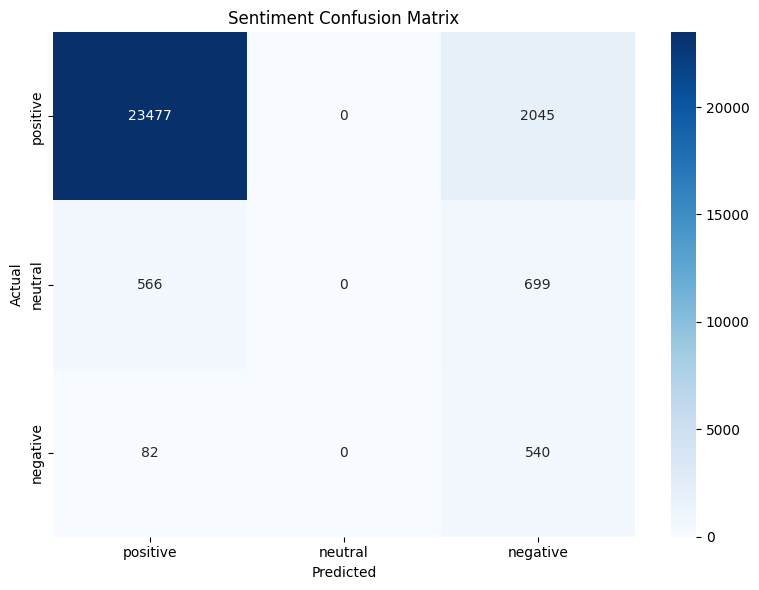

In [63]:
# @title
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# get predicted labels (normalize to match your mapped labels)
label_map = {'positive': 'positive', 'negative': 'negative', 'neutral': 'neutral'}
predicted = [label_map[r['label'].lower()] for r in results]
actual = revs_df_clean['reviews_sentiment'].tolist()

# get and show model's metrics
print(classification_report(actual, predicted, labels=list(label_map.values())))

labels = ['positive', 'neutral', 'negative']
cm = confusion_matrix(actual, predicted, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Sentiment Confusion Matrix')
plt.tight_layout()
plt.show()

# Category Clustering
- Get all unique categories
- Run categories through a model that shrinks them
  - hierarchical clustering <-
  - k-means clustering
- Create new Series with the new categories

### Preprocessing Category data
1. Split concepts in categories
2. Normalise individual categories
    - lowering all cases
    - removing punctuation
3. Filter stopwords
4. Set it all to remove duplicates

In [64]:
import re
rm_punkt = lambda x: re.sub(r'[^\w\s] ', '', x)
cat_stopwords = {'electronics', 'new', 'all', 'frys', 'e', 'computers', 'all tablets', 'tablets', 'amazon'}

categories_lst = []
for category in revs_df_clean.categories.unique():
    terms = set()
    for term in category.split(','):
        cleaned = rm_punkt(term.lower().strip())
        if cleaned and cleaned not in cat_stopwords:
            terms.add(cleaned)
    categories_lst.append(terms)

categories_lst

[{'computers tablets', 'fire tablets', 'ipad tablets'},
 {'computers tablets',
  'e-readers',
  'e-readers accessories',
  'ebook readers',
  'kindle e-readers'},
 {'computer components',
  'computers tablets',
  'fire tablets',
  'hard drives storage'},
 {'computers tablets', 'fire tablets'},
 {'computers tablets',
  'computers/tablets networking',
  'e-readers',
  'e-readers accessories',
  'electronics features',
  'ipad tablets',
  'ipads tablets',
  'kindle e-readers',
  'tablets ebook readers',
  'used:computers accessories',
  'used:tablets'},
 {'android tablets',
  'computers tablets',
  'fire tablets',
  'ipad tablets',
  'movies',
  'music',
  'tech toys'},
 {'computers tablets',
  'e-readers',
  'e-readers accessories',
  'ebook readers',
  'electronics features',
  'kindle e-readers'},
 {'computers tablets',
  'e-readers accessories',
  'ebook readers',
  'kindle e-readers'},
 {'computers tablets', 'fire tablets'},
 {'computers tablets',
  'computers/tablets networking',
  

### Clustering
- Using "sentence-transformers/all-MiniLM-L6-v2" as encoder

In [65]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


/tmp/ipykernel_17176/686373623.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


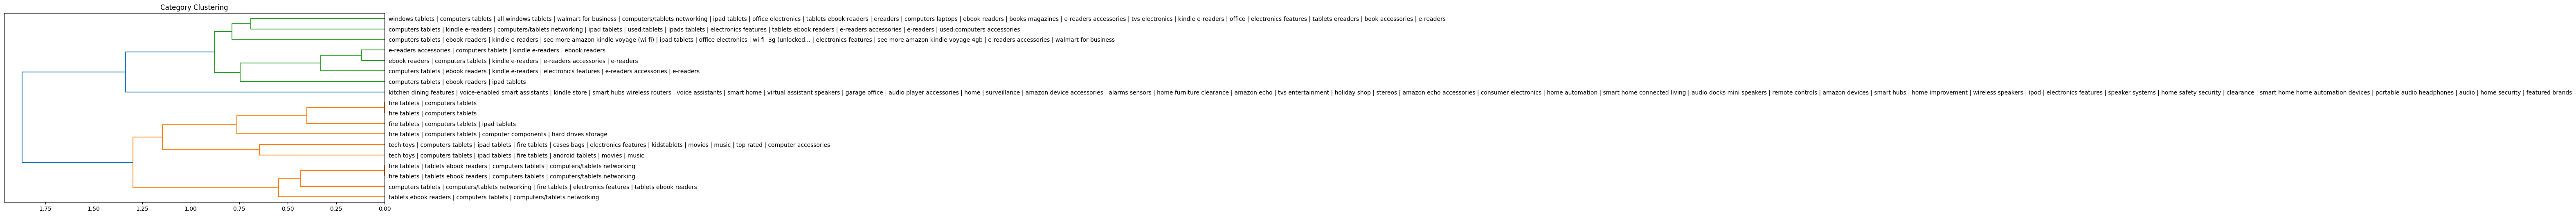

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage

# join each category's terms back into a string for TF-IDF
corpus = [' '.join(terms) for terms in categories_lst]
embeddings = model.encode(corpus)

# linkage - ward minimizes variance within clusters, good starting point
Z = linkage(embeddings, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=[' | '.join(terms) for terms in categories_lst], orientation='left', leaf_font_size=10)
plt.title('Category Clustering')
plt.tight_layout()
plt.show()

In [67]:
new_categories = [
                    'Kindle e-readers',
                    'Smart Assistants',
                    'Fire e-readers',
                    'Unbranded e-readers'
]

In [68]:
old_cats = []
for cat in revs_df_clean['categories'].unique():
  # print(repr(cat))
  old_cats.append(cat)

In [69]:
new_cats = {}
for oldKey in old_cats:
  if 'TVs Entertainment' in oldKey.split(','):
    new_cats[oldKey] = new_categories[1]
  elif 'Fire Tablets' in oldKey.split(','):
    new_cats[oldKey] = new_categories[2]
  elif 'Kindle E-readers' in oldKey.split(','):
    new_cats[oldKey] = new_categories[0]
  else:
    new_cats[oldKey] = new_categories[3]


print(len(new_cats))
new_cats

18


{'Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets': 'Fire e-readers',
 'eBook Readers,Kindle E-readers,Computers & Tablets,E-Readers & Accessories,E-Readers': 'Kindle e-readers',
 'Tablets,Fire Tablets,Electronics,Computers,Computer Components,Hard Drives & Storage,Computers & Tablets,All Tablets': 'Fire e-readers',
 'Tablets,Fire Tablets,Computers & Tablets,All Tablets': 'Fire e-readers',
 'Electronics,iPad & Tablets,All Tablets,Computers/Tablets & Networking,Tablets & eBook Readers,Computers & Tablets,E-Readers & Accessories,E-Readers,Used:Computers Accessories,Used:Tablets,Computers,iPads Tablets,Kindle E-readers,Electronics Features': 'Kindle e-readers',
 'Fire Tablets,Tablets,Computers & Tablets,All Tablets,Electronics, Tech Toys, Movies, Music,Electronics,iPad & Tablets,Android Tablets,Frys': 'Fire e-readers',
 'Kindle E-readers,Electronics Features,Computers & Tablets,E-Readers & Accessories,E-Readers,eBook Readers': 'Kindle e-readers',
 'Computer

In [70]:
revs_df_clean['category_clean'] = revs_df_clean['categories'].map(
    lambda x: new_cats.get(x, 'Unknown')
)

revs_df_clean.category_clean.unique()

array(['Fire e-readers', 'Kindle e-readers', 'Unbranded e-readers',
       'Smart Assistants'], dtype=object)

In [71]:
revs_df_clean.sample(10)

,name,brand,categories,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.text,reviews.title,reviews_sentiment,category_clean
11926,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",True,0,5,My kids had neither one had a reader or a tabl...,Good reader and tablet for my student,positive,Fire e-readers
19098,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,"Walmart for Business,Office Electronics,Tablet...",True,0,5,Loving the new paper white Kindle with its no ...,Love the Nonglare Screen,positive,Kindle e-readers
7024,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",True,0,5,Cheap price but the specs are not cheap. A pra...,Cheap price,positive,Fire e-readers
22929,"Echo (White),,,\r\nEcho (White),,,",Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",True,0,5,Best hands free speaker for a beginner. My dau...,Great hands free speaker,positive,Smart Assistants
22633,"Echo (White),,,\r\nEcho (White),,,",Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",True,0,4,"Bought this as a gift for my Dad, he loves it!...",Still learning,positive,Smart Assistants
2618,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",True,0,5,I love this kindle works great for me I will b...,Great Item,positive,Fire e-readers
16625,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",Amazon,"Tablets,Fire Tablets,Computers & Tablets,All T...",True,0,5,Grand kids love it and it picked up the networ...,"Love it, grandkids took to it immediately",positive,Fire e-readers
21577,"Echo (White),,,\r\nEcho (White),,,",Amazon,"Computers & Tablets,Tablets,All Tablets,Comput...",True,0,5,Great product. Highly recommended. Great value...,5 out of 5,positive,Fire e-readers
8483,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",True,0,4,I purchased this to replace the Ereader I had....,great little tablet for reding and research.,positive,Fire e-readers
15929,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",Amazon,"Tablets,Fire Tablets,Computers & Tablets,All T...",True,0,5,Tablet is great! I bought it for my 6 year old...,Great tablet for my little girl,positive,Fire e-readers


# Review Summarisation using LLMs
- Return individual product scores for comparison
  - Based on reviews, sentiment and other facters
  - Will most likely use another HF model for this
- Get a pre-trained LLM for the summarisation
  - Groq (cuz its free to a point)
  - A LLM model from HuggingFace
- When requested, create comprehensive sentiment-based summaries and analysis

### Product Scoring


In [72]:
df = pd.read_csv(os.path.join(curr_dir, "data", "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))
df["reviews.doRecommend"].value_counts()

,count
reviews.doRecommend,
True,15353
False,733


In [74]:
# review length as a proxy for engagement
revs_df_clean["review_length"] = revs_df_clean["reviews.text"].str.split().str.len()

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

TARGET_COL = "reviews.rating"
CANDIDATE_COLS = revs_df_clean.columns.tolist()

# Returns
def learn_weights(df: pd.DataFrame, target_col: str = "rating", candidates: list = CANDIDATE_COLS):
    '''
    Function that is used in tandom with the score_products function to find out how important each column is to the target.
    Parameters
    ----------
      df: pd.DataFrame
        Dataframe with columns whos weights are to be learnt.
      available
      target_col: str
        Column in the dataframe that the weights are to be based off of.

      candidates: list
        List of columns in the dataframe that the weights are to be learnt for.
    '''
    available = [c for c in candidates if c in df.columns and c != target_col]

    clean_cols = []
    for col in available:
        series = df[col]

        # Handle bool
        if series.dtype == bool:
            df[col] = series.astype(int)
            clean_cols.append(col)
            continue

        # Handle string sentiment labels
        if series.dtype == object:
            mapping = {"positive": 1, "neutral": 0, "negative": -1}
            mapped = series.str.lower().map(mapping)
            if mapped.notna().sum() > len(df) * 0.5:
                df[col] = mapped
                clean_cols.append(col)
                continue

        # General numeric coercion
        coerced = pd.to_numeric(series, errors="coerce")
        if coerced.notna().sum() > len(df) * 0.5:
            df[col] = coerced
            clean_cols.append(col)
        else:
            print(f"Dropped '{col}': couldn't convert to numeric")

    X = df[clean_cols].fillna(df[clean_cols].median())
    y = df[target_col].fillna(df[target_col].median())

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    model = LinearRegression().fit(X_scaled, y)

    # fix: use clean_cols here, not available
    weights = pd.Series(model.coef_, index=clean_cols).sort_values(ascending=False)
    print(f"R² on training data: {model.score(X_scaled, y):.3f}")
    return weights

weights = learn_weights(revs_df_clean, target_col=TARGET_COL)
weights

Dropped 'name': couldn't convert to numeric
Dropped 'brand': couldn't convert to numeric
Dropped 'categories': couldn't convert to numeric
Dropped 'reviews.text': couldn't convert to numeric
Dropped 'reviews.title': couldn't convert to numeric
Dropped 'category_clean': couldn't convert to numeric
R² on training data: 0.642


,0
reviews_sentiment,3.161618
reviews.doRecommend,0.121975
reviews.numHelpful,0.010083
review_length,-1.247295


In [76]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# --- Config: define signals you MIGHT have, with weights ---
SIGNAL_CONFIG = {
    # column_name : (weight, higher_is_better)
    weights.index[idx]: (weight, True) for idx, weight in enumerate(weights)
}

def score_products(df, product_col="product_id", signal_config=SIGNAL_CONFIG):
    available = {col: cfg for col, cfg in signal_config.items() if col in df.columns}

    if not available:
        raise ValueError("No recognised signal columns found in dataframe.")

    print(f"Using signals: {list(available.keys())}")

    # Re-normalise weights to sum to 1 based on what's available
    total_weight = sum(w for w, _ in available.values())

    scaler = MinMaxScaler()
    scored = df[[product_col]].copy()

    weighted_sum = np.zeros(len(df))

    for col, (weight, higher_is_better) in available.items():
        vals = df[col].fillna(df[col].median()).values.reshape(-1, 1)
        normed = scaler.fit_transform(vals).flatten()

        if not higher_is_better:
            normed = 1 - normed  # flip so lower original = higher score

        weighted_sum += normed * (weight / total_weight)

    scored["score"] = weighted_sum

    # Aggregate per product (mean across reviews)
    product_scores = (
        scored.groupby(product_col)["score"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "avg_score", "count": "review_count"})
        .sort_values("avg_score", ascending=False)
        .reset_index()
    )

    return product_scores

In [77]:
def bayesian_rank(product_scores, score_col="avg_score", count_col="review_count", C=None):
    m = product_scores[score_col].mean()  # global mean

    # C defaults to the median review count — products below this get penalised
    if C is None:
        C = product_scores[count_col].median()

    n = product_scores[count_col]

    product_scores["bayesian_score"] = (C * m + n * product_scores[score_col]) / (C + n)
    product_scores["rank"] = product_scores["bayesian_score"].rank(ascending=False).astype(int)

    return product_scores.sort_values("rank")

In [78]:
scored_products = score_products(revs_df_clean, product_col="name")
ranked_products = bayesian_rank(scored_products)
ranked_products

Using signals: ['reviews_sentiment', 'reviews.doRecommend', 'reviews.numHelpful', 'review_length']


,name,avg_score,review_count,bayesian_score,rank
12,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...",1.594021,14,1.572001,1
10,"Kindle Paperwhite,,,\r\nKindle Paperwhite,,,",1.594815,9,1.565566,2
22,Amazon 9W PowerFast Official OEM USB Charger a...,1.567771,36,1.561290,3
16,"Amazon Echo and Fire TV Power Adapter,,,\r\nAm...",1.588590,8,1.560296,4
24,"Kindle Voyage E-reader, 6 High-Resolution Disp...",1.559640,580,1.559263,5
9,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",1.595074,6,1.558936,6
19,"Kindle Dx Leather Cover, Black (fits 9.7 Displ...",1.583024,9,1.558933,7
23,"Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Specia...",1.560520,128,1.558831,8
26,Amazon Kindle Paperwhite - eBook reader - 4 GB...,1.558288,3176,1.558221,9
7,"Amazon - Fire 16GB (5th Gen, 2015 Release) - B...",1.597373,5,1.556882,10


### Summarisation with LLM